In [78]:
from pathlib import Path
import os

import pandas as pd
import numpy as np
import plotly.express as px
import matplotlib.pyplot as plt

from rdkit.Chem import Descriptors
import streamlit as st
from torch_geometric.data import Dataset
from torch_geometric.loader import DataLoader
import torch
from sklearn.decomposition import PCA

from polynet.app.options.data import DataOptions
from polynet.app.options.state_keys import ExplainModelStateKeys, ProjectionPlotStateKeys
from polynet.app.services.explain_model import analyse_graph_embeddings, explain_model
from polynet.app.services.model_training import load_gnn_model
from polynet.app.utils import extract_number
from polynet.options.col_names import get_predicted_label_column_name, get_true_label_column_name
from polynet.options.enums import (
    DataSets,
    DimensionalityReduction,
    ExplainAlgorithms,
    ImportanceNormalisationMethods,
    ProblemTypes,
    Results,
)

from crystals_experiment.crystal_graph import crystal_graph_dataset

In [29]:
model_name = "CGGNN_1.pt"
model_dir = "C:\\Users\\ezxac5\\Documents\\GitHub\\PolyNet\\crystals_experiment\\results\\models"

In [30]:
device="cpu"
path = os.path.join(model_dir, model_name)
model = torch.load(path, weights_only=False, map_location=torch.device('cpu'))

In [31]:
data_options = DataOptions

In [32]:
predicted_col_name = get_predicted_label_column_name(target_variable_name=data_options.target_variable_name, model_name=model._name)

In [33]:
# get the number of the iteration of the model
iteration = extract_number(model_name)

In [34]:
# Load training/validation/test data
general_dir = Path("crystals_experiment")

targets = pd.read_csv(general_dir / 'data/id_prop.csv', header=None)

dataset = crystal_graph_dataset(
    root= general_dir / "data",
    max_d=3.5,
    step=0.5,
    vor_cut_off=3.5,
    targets=targets
)


In [35]:
pred_path = r'C:\Users\ezxac5\Documents\GitHub\PolyNet\crystals_experiment\results'
pred_file = os.path.join(pred_path, 'predictions.csv')

In [36]:
preds = pd.read_csv(pred_file)

In [37]:
preds.describe()

,Unnamed: 0,Bootstrap Iteration,True target,GCN Predicted target,GraphSAGE Predicted target,TransformerConvGNN Predicted target,GAT Predicted target,MPNN Predicted target,CGGNN Predicted target
count,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000,150.000000
mean,14.500000,3.000000,1.981340,1.871503,1.867797,1.932339,1.922240,1.967024,1.938885
std,8.684438,1.418951,0.312987,0.326203,0.332473,0.312602,0.302614,0.292989,0.317118
min,0.000000,1.000000,1.360000,1.242565,0.887338,1.234504,1.211018,1.347398,1.262743
25%,7.000000,2.000000,1.710000,1.560142,1.615683,1.658221,1.672336,1.735917,1.659480
50%,14.500000,3.000000,2.100000,1.961499,1.942987,2.058047,2.006002,2.077632,2.050724
75%,22.000000,4.000000,2.240000,2.164427,2.127104,2.194180,2.154854,2.208679,2.189123
max,29.000000,5.000000,2.290400,2.315485,2.569966,2.283917,2.423288,2.341418,2.360597


In [38]:
# get the name of the predicted col name for the model selected by the user
predicted_col_name = get_predicted_label_column_name(target_variable_name=data_options.target_variable_name, model_name=model._name)

In [39]:
# get the number of the iteration of the model
iteration = extract_number(model_name)
print(iteration)

1


In [40]:
# filter the predictions to get only the predictions of the corresponding iteration and the corresponding model
preds_projection = preds.loc[preds['Bootstrap Iteration'] == iteration, [Results.Set.value, 'GCN Predicted target']]

In [41]:
print(preds_projection)

           Set  GCN Predicted target
0        Train              2.054973
1        Train              1.348325
2        Train              1.823892
3        Train              1.347385
4        Train              1.348551
5        Train              1.476054
6        Train              1.836276
7        Train              1.425391
8        Train              1.457647
9        Train              1.999788
10       Train              2.065383
11       Train              1.768143
12       Train              1.960074
13       Train              1.999695
14       Train              2.142323
15       Train              2.275177
16       Train              1.840641
17       Train              2.301923
18       Train              2.288837
19       Train              1.733558
20       Train              1.525847
21       Train              1.270800
22       Train              1.966527
23       Train              1.974201
24  Validation              2.123911
25  Validation              2.281770
2

In [42]:
def get_graph_embeddings(dataset, model) -> np.ndarray:
    """
    Get graph embeddings for the dataset using the provided model.

    Args:
        dataset (CustomPolymerGraph): The dataset containing graph data.
        model: The model used to generate embeddings.

    Returns:
        np.ndarray: An array of graph embeddings.
    """
    loader = DataLoader(dataset=dataset, batch_size=1, shuffle=False)
    embeddings = []
    idx = []

    for batch in loader:
        with torch.no_grad():
            embedding = model.get_graph_embedding(
                x=batch.x,
                edge_index=batch.edge_index,
                edge_attr=batch.edge_attr,
                batch_index=batch.batch,
                monomer_weight=batch.weight_monomer,
            )
            embeddings.append(embedding.cpu().numpy())
            idx.append(batch.idx)

    idx = np.array(idx).flatten().tolist()
    embeddings = pd.DataFrame(np.concatenate(embeddings, axis=0), index=idx)

    return embeddings


In [43]:
def analyse_graph_embeddings(
    model,
    dataset,
    labels: pd.Series,
    style_by: pd.Series,
    mols_to_plot: list,
    reduction_method: str,
    reduction_parameters: dict,
    colormap: str,
):

    embeddings = get_graph_embeddings(dataset, model)

    if reduction_method == DimensionalityReduction.tSNE:
        tsne = TSNE(n_components=2, **reduction_parameters)
        reduced = tsne.fit_transform(embeddings)

    elif reduction_method == DimensionalityReduction.PCA:
        pca = PCA(n_components=2, **reduction_parameters)
        reduced = pca.fit_transform(embeddings)

    reduced_embeddings = pd.DataFrame(reduced, index=embeddings.index, columns=["Dim1", "Dim2"])
    reduced_embeddings = reduced_embeddings.loc[mols_to_plot]
    reduced_embeddings = reduced_embeddings.to_numpy()

    labels = labels.loc[mols_to_plot]

    projection_fig = plot_projection_embeddings(
        reduced_embeddings, labels=labels, cmap=colormap, style=style_by
    )
    st.pyplot(projection_fig, use_container_width=True)

In [44]:
embeddings = get_graph_embeddings(dataset, model)

In [45]:
print(embeddings)

            0           1          2           3          4           5    \
c1     2.503614   -0.265298  -0.568855   93.603348  -0.548451   44.743088   
c10   -0.420120   -0.278243  80.660019  100.654243  28.447729   -0.436203   
c11    1.848241   -0.274719   2.593455   87.442825  15.660470   15.299118   
c12    7.694309   -0.264304  -0.529800   87.380051   0.930894   53.417278   
c13   53.597591   41.145599  -0.541479   39.008560  15.672858  100.728241   
c14   76.810860   58.045135  -0.534819   29.912868  39.903263  101.281113   
c15   92.645348   84.514359  -0.565484   17.691816  25.622139  143.520538   
c16  157.105682  164.458923  -0.560204    2.935368  51.498158  208.812683   
c17  128.005371  133.725723  -0.535814    9.605686  74.031876  130.840363   
c18  108.371834  127.159042   5.614489   -0.629085  86.468018   55.677094   
c19    0.110113   -0.292389  33.196804   42.315784  18.640120    2.001989   
c2    -0.399259   -0.307557  94.229004   -0.477765  44.452801   -0.528943   

In [46]:
#analyse_graph_embeddings(model, dataset)

In [47]:
embeddings = embeddings.sort_index(key=lambda idx: idx.str.extract(r'(\d+)').astype(int)[0])

In [48]:
print(embeddings)

            0           1          2           3          4           5    \
c1     2.503614   -0.265298  -0.568855   93.603348  -0.548451   44.743088   
c2    -0.399259   -0.307557  94.229004   -0.477765  44.452801   -0.528943   
c3     4.391834   -0.256338  -0.572624  112.192474  -0.499542   56.663700   
c4    35.850643   44.479610   2.392344    2.872445  35.140221   22.417604   
c5    66.207291   42.805107  -0.565214   47.748184  21.092627  118.830238   
c6    77.237328   79.733597  -0.224224   11.904148  48.745605   85.492546   
c7    70.278755   40.910347  -0.572824   57.105705  16.761269  138.497635   
c8    -0.218097   -0.261492   5.948438  122.812424   3.312110    6.250665   
c9    11.573630   -0.252955  -0.572770  106.703285  -0.110588   74.923088   
c10   -0.420120   -0.278243  80.660019  100.654243  28.447729   -0.436203   
c11    1.848241   -0.274719   2.593455   87.442825  15.660470   15.299118   
c12    7.694309   -0.264304  -0.529800   87.380051   0.930894   53.417278   

In [50]:
pca = PCA(n_components=2, random_state=42)
reduced = pca.fit_transform(embeddings)

In [51]:
print(embeddings.index)

Index(['c1', 'c2', 'c3', 'c4', 'c5', 'c6', 'c7', 'c8', 'c9', 'c10', 'c11',
       'c12', 'c13', 'c14', 'c15', 'c16', 'c17', 'c18', 'c19', 'c20', 'c21'],
      dtype='object')


In [64]:
# Create merged dataframe for plot
components_df = pd.DataFrame(data=reduced,\
                            columns=['0', '1'])



plot_df = pd.concat([pd.DataFrame(embeddings.index), components_df, targets[1]], axis=1)
plot_df.columns = ['Id', '0', '1', 'Target TC']

In [70]:
loadings = pca.components_.T*np.sqrt(pca.explained_variance_)

In [73]:
print(components_df)

             0           1
0  -366.396210  185.791718
1   -24.471138 -650.182556
2  -435.919037  322.882050
3   163.947418 -305.853027
4    45.206409  239.842606
5   328.525696  -76.492378
6    54.314655  308.196899
7  -422.444153   21.965940
8  -427.487061  380.243195
9  -308.601593 -329.241302
10 -251.318359  -95.099258
11 -322.587158  153.428650
12   56.379986   99.253380
13  225.974258   71.384918
14  329.285339  165.533188
15  773.294189  293.538055
16  643.328186   93.943176
17  641.935974 -233.343582
18 -152.180237 -366.633728
19 -236.641006 -270.162659
20 -314.146393   -8.995148


In [65]:
print(plot_df)

     Id           0           1  Target TC
0    c1 -366.396210  185.791718       2.14
1    c2  -24.471138 -650.182556       2.04
2    c3 -435.919037  322.882050       2.29
3    c4  163.947418 -305.853027       1.73
4    c5   45.206409  239.842606       1.58
5    c6  328.525696  -76.492378       1.47
6    c7   54.314655  308.196899       1.52
7    c8 -422.444153   21.965940       2.24
8    c9 -427.487061  380.243195       2.24
9   c10 -308.601593 -329.241302       2.16
10  c11 -251.318359  -95.099258       1.97
11  c12 -322.587158  153.428650       2.21
12  c13   56.379986   99.253380       1.67
13  c14  225.974258   71.384918       1.45
14  c15  329.285339  165.533188       1.71
15  c16  773.294189  293.538055       1.90
16  c17  643.328186   93.943176       1.36
17  c18  641.935974 -233.343582       1.40
18  c19 -152.180237 -366.633728       2.06
19  c20 -236.641006 -270.162659       1.97
20  c21 -314.146393   -8.995148       2.02


In [83]:
import plotly.io as pio
pio.templates.default = "plotly"

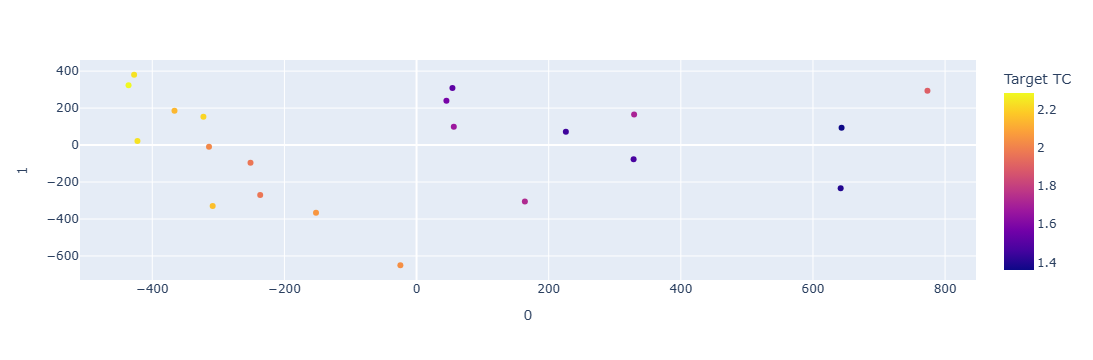

In [84]:
# Generate PCA plot
fig = px.scatter(plot_df, x='0', y='1', color='Target TC', hover_name='Id', hover_data=['Target TC'])
fig.show()
#fig.write_html(results_dir + '\\' + f"{filename}_PCA-plot.html")

In [81]:
plt.figure(figsize=(8, 6))
plt.scatter(plot_df["0"], plot_df["1"], c='royalblue', edgecolors='k', alpha=0.7)
plt.xlabel(f'PCA 1')
plt.ylabel(f'PCA 2')
plt.title('PCA of GNN Extracted Features (Pyrochlore Dataset)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

C:\Users\ezxac5\AppData\Local\Temp\ipykernel_11956\1305918838.py:7: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown

